In [3]:
# Kütüphanelerimizi import edelim

from collections import Counter
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

In [6]:
# Örnek veri setimizi oluşturalım
# Bazı kelimlerin sık geçmesini istiyoruz
# Böylece n-gram modellerinin nasıl çalıştığını daha iyi görebiliriz

corpus = [
    "I love you",
    "I love apple",
    "I love programming",
    "You love me",
    "She loves apple",
    "They love you",
    "I love you and you love me",
]

In [10]:
# Veri setimizi tokenize edelim
# Tokenize etmek için bu sefer word_tokenize fonksiyonunu kullanacağız. Bunun sebebi python'da bir işlem için birden çok yöntemi kullanabileceğimizi göstermek

tokens = [word_tokenize(sentence.lower()) for sentence in corpus]
tokens

[['i', 'love', 'you'],
 ['i', 'love', 'apple'],
 ['i', 'love', 'programming'],
 ['you', 'love', 'me'],
 ['she', 'loves', 'apple'],
 ['they', 'love', 'you'],
 ['i', 'love', 'you', 'and', 'you', 'love', 'me']]

In [14]:
# N-gram modelini oluşturalım

bigrams = []
for token_list in tokens:
    bigrams.extend(list(ngrams(token_list,2))) # bigram oluşturduğumuz için 2 kullandık

bigrams

[('i', 'love'),
 ('love', 'you'),
 ('i', 'love'),
 ('love', 'apple'),
 ('i', 'love'),
 ('love', 'programming'),
 ('you', 'love'),
 ('love', 'me'),
 ('she', 'loves'),
 ('loves', 'apple'),
 ('they', 'love'),
 ('love', 'you'),
 ('i', 'love'),
 ('love', 'you'),
 ('you', 'and'),
 ('and', 'you'),
 ('you', 'love'),
 ('love', 'me')]

extend() fonksiyonu, listelere birden fazla öğeyi eklemek için kullanılır. Bu fonksiyon, bir listenin sonuna başka bir iterable (liste, demet, set, vs.) öğelerini tek tek ekler. Yani append() gibi tek bir öğe değil, tüm öğeleri ekler.

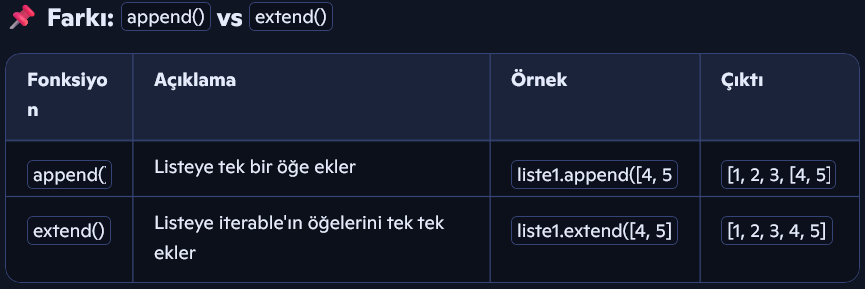
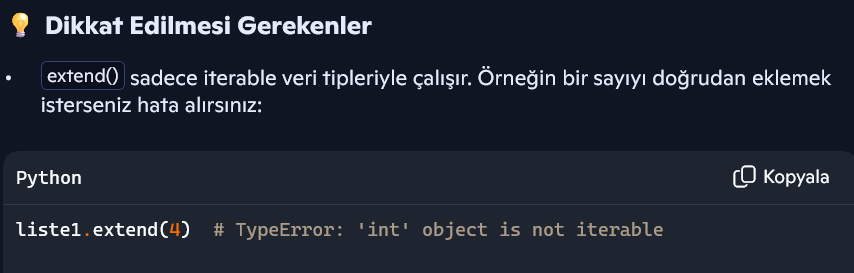

In [ ]:
# Tokenize ettiğimiz cümlelerimizi bigramlara çevirdik.

print(f"Token'larımız: {tokens}\n")
print(f"Bigram'larımız: {bigrams}\n")

# Örneği incelediğimizde love'dan sonra you var, apple var, programming var, me var, you var, you var gibi gidiyoruz...
#... büyük bir veri setinde bu şekilde love'dan sonra hangi kelimenin gelme olasılığı daha yüksekse o kelimeyi tahmin edebiliriz

Token'larımız: [['i', 'love', 'you'], ['i', 'love', 'apple'], ['i', 'love', 'programming'], ['you', 'love', 'me'], ['she', 'loves', 'apple'], ['they', 'love', 'you'], ['i', 'love', 'you', 'and', 'you', 'love', 'me']]

Bigram'larımız: [('i', 'love'), ('love', 'you'), ('i', 'love'), ('love', 'apple'), ('i', 'love'), ('love', 'programming'), ('you', 'love'), ('love', 'me'), ('she', 'loves'), ('loves', 'apple'), ('they', 'love'), ('love', 'you'), ('i', 'love'), ('love', 'you'), ('you', 'and'), ('and', 'you'), ('you', 'love'), ('love', 'me')]



In [ ]:
# Bigram'daki frekansları sayalım

bigram_freq = Counter(bigrams)
bigram_freq

# Örneğin burda bize "i'dan sonra ne gelecek" diye sorulsa olasılıksal olarak baktığımızda "love" cevabını verebiliriz... 
# ...çünkü "i love" bigramı 4 kez geçmiş. Diğer bigramlar ise 1 kez geçmiş. Bu yüzden "love" kelimesinin gelme olasılığı daha yüksek.

Counter({('i', 'love'): 4,
         ('love', 'you'): 3,
         ('you', 'love'): 2,
         ('love', 'me'): 2,
         ('love', 'apple'): 1,
         ('love', 'programming'): 1,
         ('she', 'loves'): 1,
         ('loves', 'apple'): 1,
         ('they', 'love'): 1,
         ('you', 'and'): 1,
         ('and', 'you'): 1})

In [18]:
# Bigram oluşturmuştuk. Bu sefer trigram oluşturalım

trigrams = []
for token_list in tokens:
    trigrams.extend(list(ngrams(token_list,3)))

trigrams

[('i', 'love', 'you'),
 ('i', 'love', 'apple'),
 ('i', 'love', 'programming'),
 ('you', 'love', 'me'),
 ('she', 'loves', 'apple'),
 ('they', 'love', 'you'),
 ('i', 'love', 'you'),
 ('love', 'you', 'and'),
 ('you', 'and', 'you'),
 ('and', 'you', 'love'),
 ('you', 'love', 'me')]

In [19]:
# Trigram frekanslarını sayalım
trigram_freq = Counter(trigrams)
trigram_freq

Counter({('i', 'love', 'you'): 2,
         ('you', 'love', 'me'): 2,
         ('i', 'love', 'apple'): 1,
         ('i', 'love', 'programming'): 1,
         ('she', 'loves', 'apple'): 1,
         ('they', 'love', 'you'): 1,
         ('love', 'you', 'and'): 1,
         ('you', 'and', 'you'): 1,
         ('and', 'you', 'love'): 1})

In [22]:
# "I love" bigramından sonra "you" veya "apple" gelme olasılıklarını hesaplayalım
# "I love ______"

bigram = ("i","love")
prob_you = trigram_freq[("i","love","you")]/bigram_freq[bigram]
prob_apple = trigram_freq[("i","love","apple")]/bigram_freq[bigram]

print(f"I love'dan sonra you gelme olasılığı = {prob_you}")
print(f"I love'dan sonra apple gelme olasılığı = {prob_apple}")

I love'dan sonra you gelme olasılığı = 0.5
I love'dan sonra apple gelme olasılığı = 0.25
